# House Price Prediction with Linear Regression

**Task:** Build a linear regression model to predict house prices based on property features.

**Dataset:** `Housing.csv` — 546 residential properties with 13 columns.

---
### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Load & Explore Data |
| 3 | Data Cleaning |
| 4 | Feature Engineering & Encoding |
| 5 | Feature Selection |
| 6 | Model Training (Linear Regression) |
| 7 | Model Evaluation (MSE, RMSE, R²) |
| 8 | Visualization |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('All libraries loaded!')

All libraries loaded!


## 2. Load Dataset & Initial Exploration

In [2]:
# Load the housing dataset
df = pd.read_csv('Housing.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Check column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# Statistical summary of numerical features
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
# Check for missing values — important before modeling
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
# Check unique values for categorical columns
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


## 3. Data Cleaning

In [7]:
# Drop exact duplicate rows (if any)
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f'Rows removed (duplicates): {before - df.shape[0]}')
print(f'Clean shape: {df.shape}')

Rows removed (duplicates): 0
Clean shape: (545, 13)


## 4. Feature Engineering & Encoding

> Binary `yes/no` columns are encoded as `1/0`. The `furnishingstatus` column is one-hot encoded (drop first to avoid multicollinearity).

In [8]:
# Map binary yes/no columns to 1 and 0
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))

# One-hot encode furnishingstatus (drop first to avoid dummy variable trap)
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print('Columns after encoding:')
print(df.columns.tolist())
df.head(3)

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False


## 5. Feature Selection & Correlation Analysis

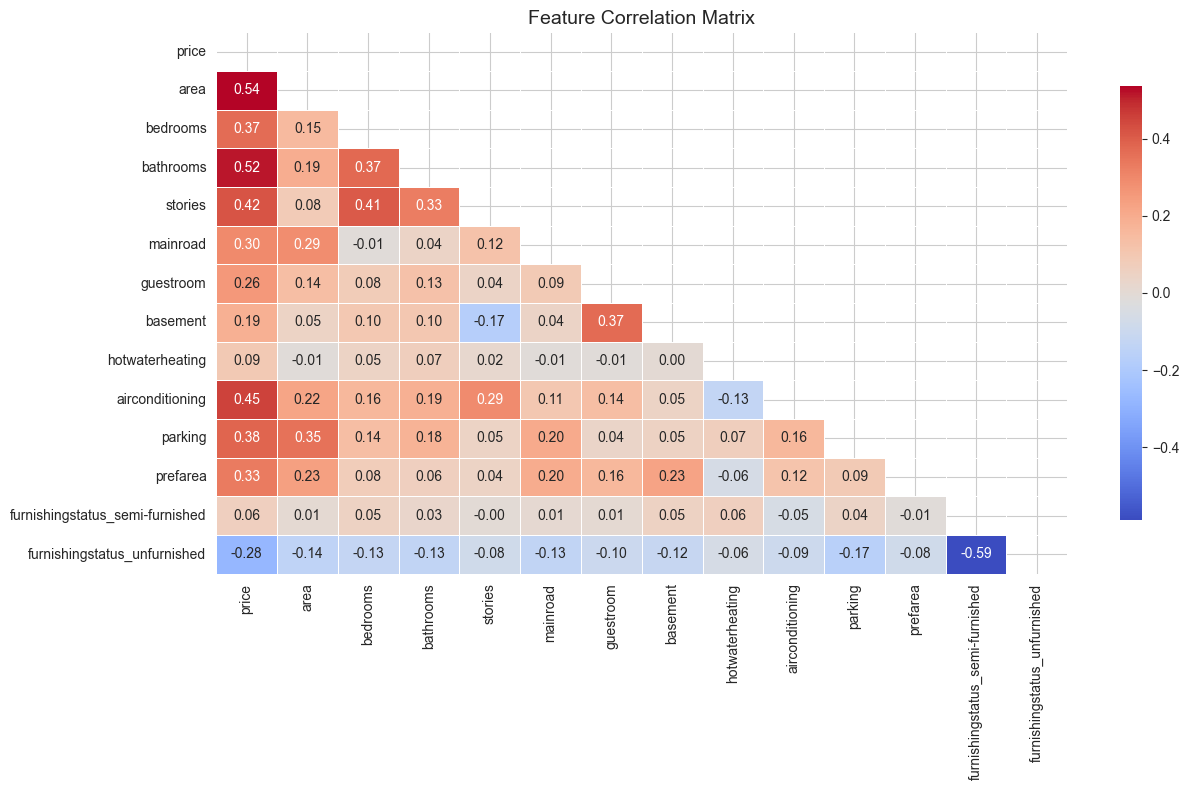

In [9]:
# Correlation heatmap — identifies which features relate most to price
plt.figure(figsize=(13, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

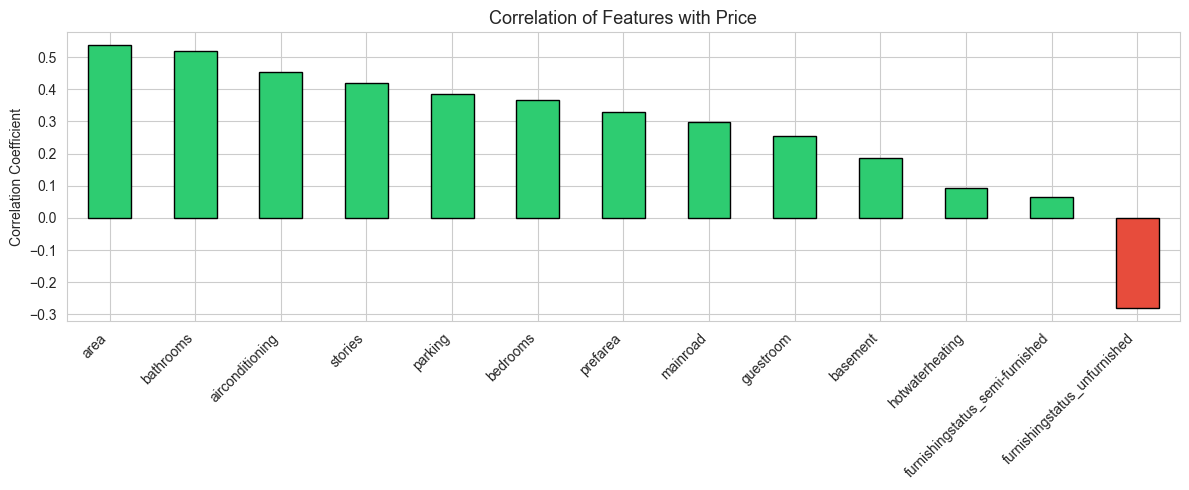

In [10]:
# Show correlation of each feature with the target (price)
corr_with_price = corr['price'].drop('price').sort_values(ascending=False)

corr_with_price.plot(kind='bar', color=['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_price],
                      edgecolor='black')
plt.title('Correlation of Features with Price', fontsize=13)
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

Features shape : (545, 13)
Target shape   : (545,)


## 6. Model Training

In [12]:
# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 436
Testing samples  : 109


In [13]:
# Scale features — StandardScaler improves numerical stability
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit only on train
X_test_sc  = scaler.transform(X_test)       # apply same scale to test

In [14]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_sc, y_train)

print('Model trained successfully!')
print(f'Intercept : {model.intercept_:,.0f}')

Model trained successfully!
Intercept : 4,706,527


In [15]:
# Display feature coefficients — shows how each feature influences price
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print('Feature Coefficients:')
coef_df

Feature Coefficients:


,Feature,Coefficient
2,bathrooms,521879.027748
0,area,519552.416340
8,airconditioning,365157.393851
3,stories,349251.438906
10,prefarea,266656.351993
9,parking,192005.953667
6,basement,187067.803214
7,hotwaterheating,149862.702991
4,mainroad,128498.628215
5,guestroom,88768.667686


## 7. Model Evaluation

> **Metrics used:**
> - **MAE** — Mean Absolute Error (average error in same unit as price)
> - **MSE** — Mean Squared Error (penalizes large errors more)
> - **RMSE** — Root Mean Squared Error (same unit as price)
> - **R²** — Coefficient of Determination (1.0 = perfect fit)

In [16]:
# Predict on test set
y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=== Model Performance on Test Set ===')
print(f'MAE  : {mae:>15,.2f}')
print(f'MSE  : {mse:>15,.2f}')
print(f'RMSE : {rmse:>15,.2f}')
print(f'R²   : {r2:>15.4f}')

=== Model Performance on Test Set ===
MAE  :      970,043.40
MSE  : 1,754,318,687,330.67
RMSE :    1,324,506.96
R²   :          0.6529


In [17]:
# Also check performance on training set to detect overfitting
y_train_pred = model.predict(X_train_sc)
r2_train = r2_score(y_train, y_train_pred)

print(f'R² on Training Set : {r2_train:.4f}')
print(f'R² on Test Set     : {r2:.4f}')
print(f'\nDifference (overfitting check): {abs(r2_train - r2):.4f}')

R² on Training Set : 0.6859
R² on Test Set     : 0.6529

Difference (overfitting check): 0.0330


## 8. Visualization

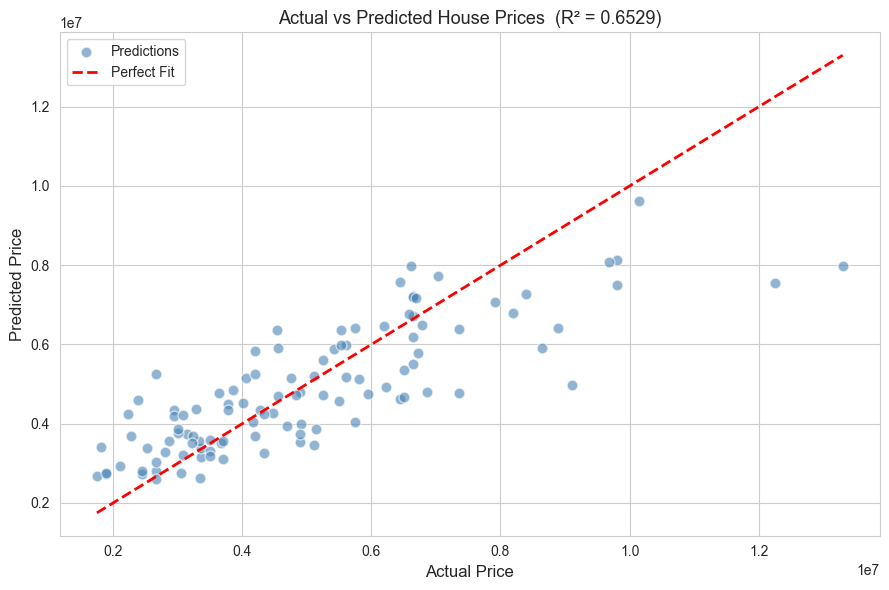

In [18]:
# Plot: Actual vs Predicted prices
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60, label='Predictions')

# Perfect prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

ax.set_xlabel('Actual Price', fontsize=12)
ax.set_ylabel('Predicted Price', fontsize=12)
ax.set_title(f'Actual vs Predicted House Prices  (R² = {r2:.4f})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

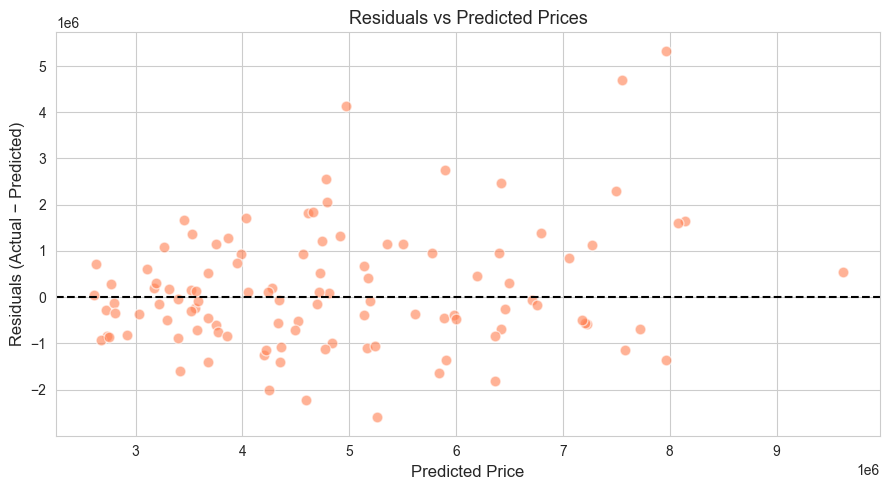

In [19]:
# Residuals plot — residuals should be randomly scattered around zero
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', s=60)
ax.axhline(0, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price', fontsize=12)
ax.set_ylabel('Residuals (Actual − Predicted)', fontsize=12)
ax.set_title('Residuals vs Predicted Prices', fontsize=13)
plt.tight_layout()
plt.show()

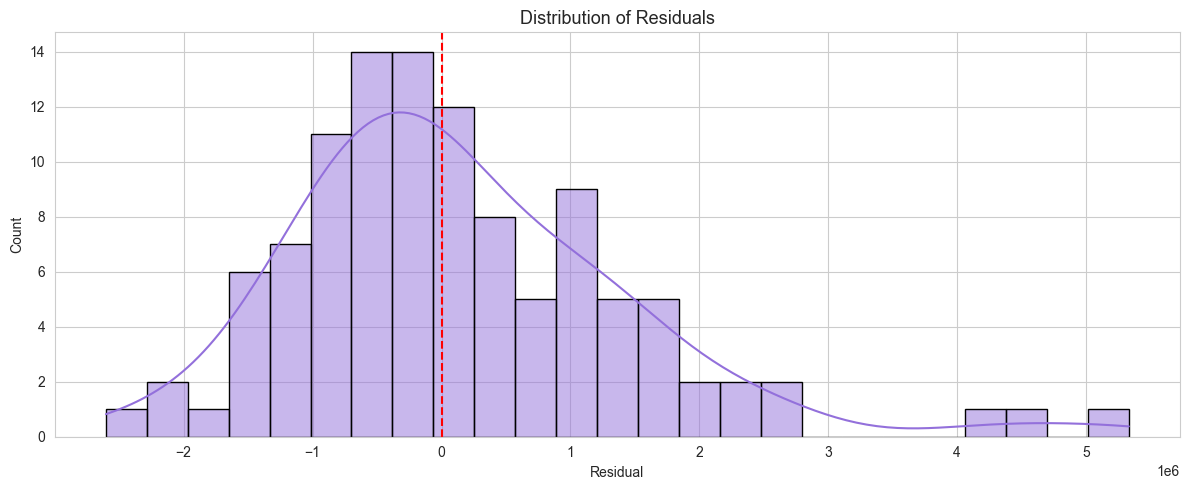

In [20]:
# Residuals distribution — should be approximately normal for linear regression
sns.histplot(residuals, kde=True, bins=25, color='mediumpurple', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals', fontsize=13)
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

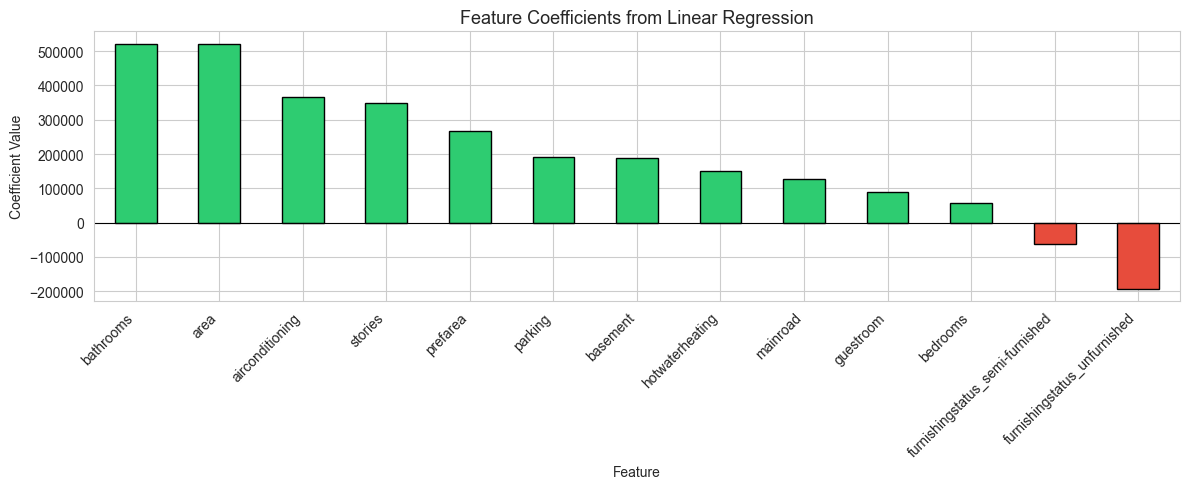

In [21]:
# Feature coefficient bar chart — positive = increases price, negative = decreases
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
coef_df.plot(x='Feature', y='Coefficient', kind='bar',
             color=colors, edgecolor='black', legend=False)
plt.title('Feature Coefficients from Linear Regression', fontsize=13)
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

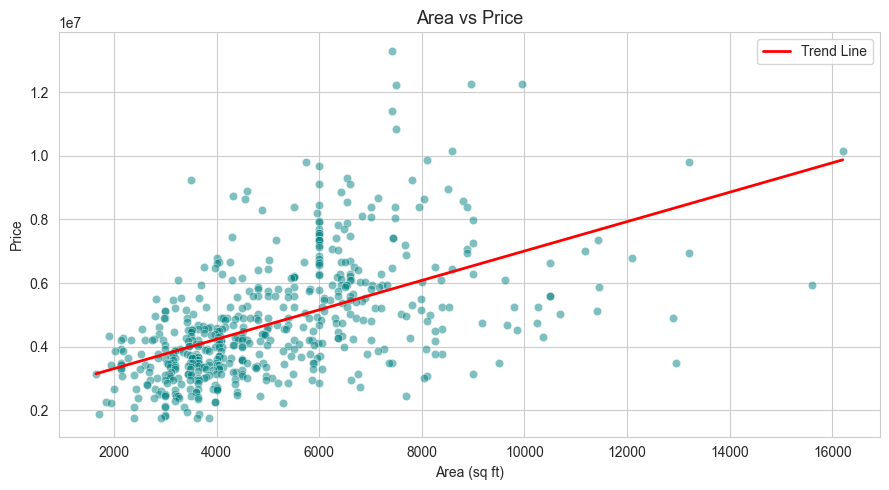

In [22]:
# Scatter plot: Area vs Price (most correlated feature)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='area', y='price', alpha=0.5, color='teal')

# Add trend line
m, b = np.polyfit(df['area'], df['price'], 1)
plt.plot(sorted(df['area']), [m * x + b for x in sorted(df['area'])],
         color='red', lw=2, label='Trend Line')

plt.title('Area vs Price', fontsize=13)
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

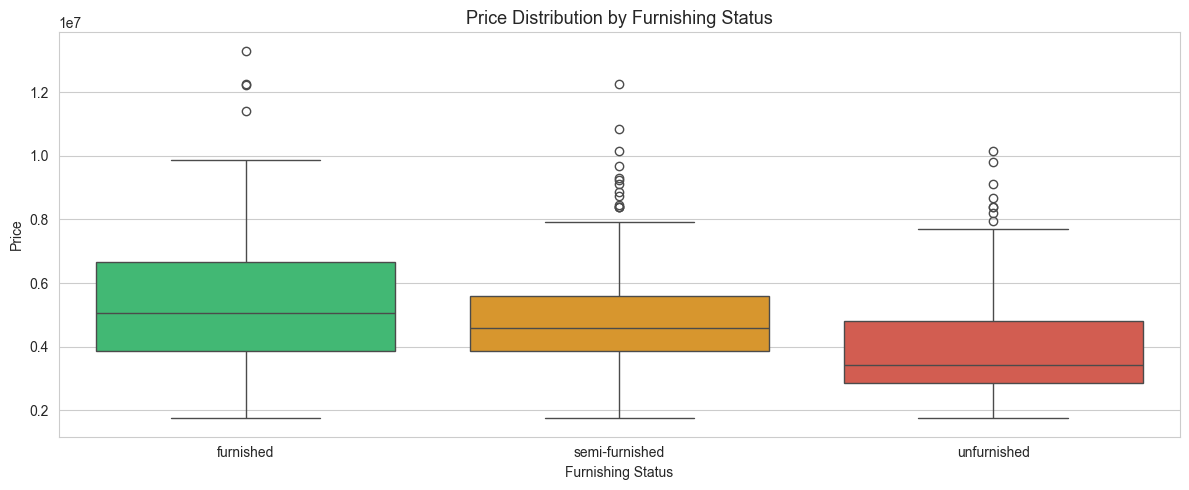

In [23]:
# Price distribution by furnishing status
# Reconstruct furnishingstatus for plotting
df_plot = df.copy()
df_plot['furnishingstatus'] = 'furnished'
df_plot.loc[df_plot.get('furnishingstatus_semi-furnished', pd.Series(False, index=df.index)) == 1, 'furnishingstatus'] = 'semi-furnished'
df_plot.loc[df_plot.get('furnishingstatus_unfurnished', pd.Series(False, index=df.index)) == 1, 'furnishingstatus'] = 'unfurnished'

sns.boxplot(data=df_plot, x='furnishingstatus', y='price',
            palette={'furnished': '#2ecc71', 'semi-furnished': '#f39c12', 'unfurnished': '#e74c3c'})
plt.title('Price Distribution by Furnishing Status', fontsize=13)
plt.xlabel('Furnishing Status')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

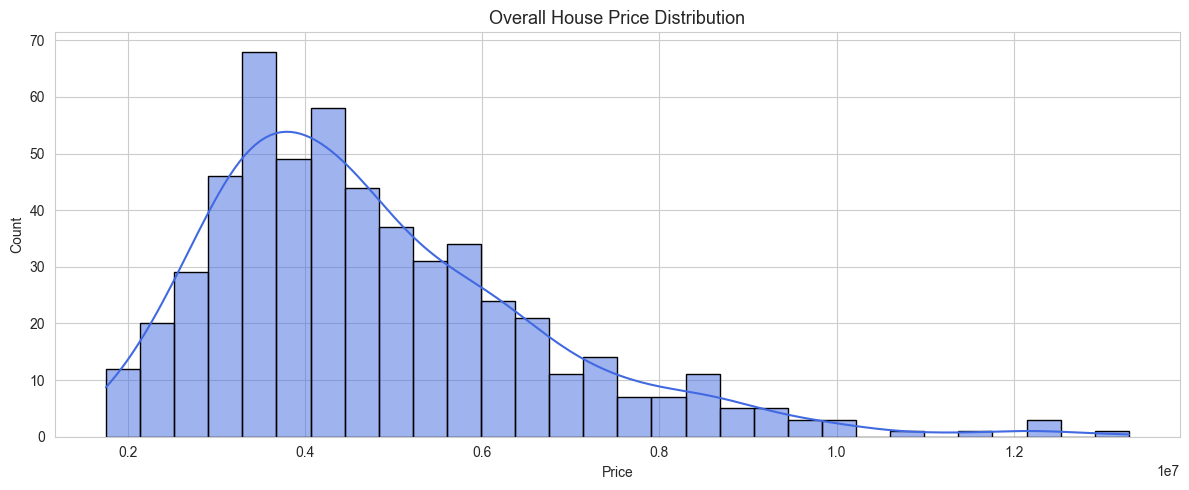

In [24]:
# Price distribution histogram
sns.histplot(df['price'], bins=30, kde=True, color='royalblue', edgecolor='black')
plt.title('Overall House Price Distribution', fontsize=13)
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 9. Predict Price for a New House

In [25]:
# Sample new house — must match the exact feature columns used in training
new_house = pd.DataFrame([{
    'area': 5000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 1,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 1,
    'prefarea': 1,
    'furnishingstatus_semi-furnished': 0,
    'furnishingstatus_unfurnished': 0
}])

# Scale and predict
new_house_sc = scaler.transform(new_house)
predicted_price = model.predict(new_house_sc)[0]

print(f'Predicted Price for the New House: ₹ {predicted_price:,.0f}')

Predicted Price for the New House: ₹ 7,078,386


## 10. Summary

| Item | Detail |
|------|--------|
| Dataset | Housing.csv — 546 properties, 13 columns |
| Target Variable | `price` |
| Encoding | Binary → 0/1 mapping; `furnishingstatus` → One-Hot Encoding |
| Scaling | StandardScaler (zero mean, unit variance) |
| Algorithm | Linear Regression (`sklearn.linear_model.LinearRegression`) |
| Train / Test Split | 80% / 20% |
| Key Evaluation Metrics | MAE, MSE, RMSE, R² |
| Top Influencing Features | `area`, `airconditioning`, `bathrooms`, `prefarea` |

> **Interpretation:** A positive coefficient means the feature pushes price up; a negative coefficient means it pulls price down. The R² score tells how much variance in price the model explains.